<a href="https://colab.research.google.com/github/CatherineMatangu/MyRepo_2026_Analytics2/blob/main/VideoAnalyticsPublicSafetyNairobi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Generating simulated video: nairobi_street_sim.mp4 ---
Simulated video saved as nairobi_street_sim.mp4

--- Analyzing video: nairobi_street_sim.mp4 ---
Video analysis complete.

--- Generating visualizations and summary ---


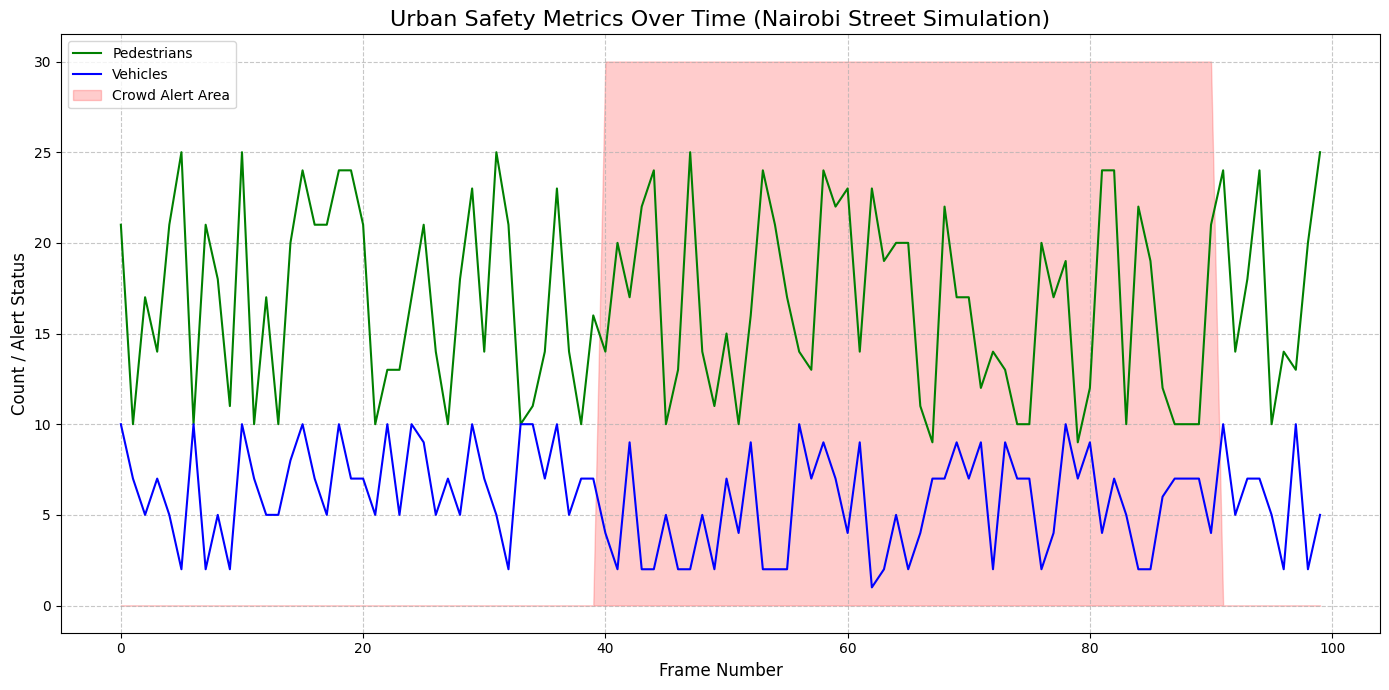

Plot saved as safety_metrics_plot_complete.png

--- Safety Metrics Summary ---
Average Pedestrian Count: 16.83
Average Vehicle Count: 5.93
Total Crowd Alert Frames: 51

--- Analysis Insights ---
The plot visually represents the dynamic changes in pedestrian and vehicle traffic.
The 'Crowd Alert Area' highlights periods of potential concern, demonstrating how video analytics
can be used for real-time incident detection and proactive safety measures in urban environments.


In [1]:
"""
Video Analytics for Public Safety in Kenyan Cities

This script provides a complete, self-contained implementation of the video analytics project. It simulates urban video data, processes it to detect
objects and anomalies, extracts safety metrics, and visualizes the results.

Contents:
1.  **Introduction**: Overview of the project and its objectives.
2.  **Setup**: Installation of necessary libraries.
3.  **Simulated Video Generation**: Function to create a synthetic video of a Nairobi street.
4.  **Video Analysis**: Function to process the simulated video for object detection and anomaly detection.
5.  **Metrics Visualization**: Function to plot the extracted safety metrics and provide a summary.
6.  **Execution**: Main block to run the entire workflow.
"""

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. Introduction ---
# This project explores the application of video analytics to enhance public safety in Kenyan
# cities. Leveraging advanced computer vision techniques, the aim is to identify potential
# safety risks, analyze urban patterns, and propose actionable strategies. Due to limitations
# in accessing live CCTV feeds, this project utilizes simulated video data.

# --- 2. Setup ---
# Ensure you have the necessary libraries installed. If running in a Jupyter Notebook
# or a similar environment, you might need to run the following command:
# !pip install opencv-python-headless pandas matplotlib numpy

# Set random seed for reproducibility
np.random.seed(42)

# --- 3. Simulated Video Generation ---
def create_simulated_video(filename="nairobi_street_sim.mp4", num_frames=100):
    """
    Generates a simulated video representing a Nairobi street scene.
    The video incorporates:
    - Pedestrians: Represented by green bounding boxes.
    - Vehicles: Represented by blue bounding boxes.
    - Crowd Event: A simulated anomaly highlighted with a red bounding box and "ALERT" text
                   during a specific frame range (frames 40-90).

    Args:
        filename (str): The name of the output video file.
        num_frames (int): The total number of frames in the simulated video.
    """
    print(f"\n--- Generating simulated video: {filename} ---")
    width, height = 640, 480
    # Using 'mp4v' codec for broader compatibility
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(filename, fourcc, 10.0, (width, height))

    if not out.isOpened():
        print("Error: Could not open video writer.")
        return

    for i in range(num_frames):
        # Create a dark gray background for the street
        frame = np.ones((height, width, 3), dtype=np.uint8) * 100

        # Draw road area (simulated segmentation - gray area)
        cv2.rectangle(frame, (100, 0), (540, height), (150, 150, 150), -1)

        # Simulate Pedestrians (Green bounding boxes)
        # Randomly place 3 to 8 pedestrians per frame
        num_peds = np.random.randint(3, 8)
        for _ in range(num_peds):
            x = np.random.randint(100, 540 - 15) # Ensure box stays within bounds
            y = np.random.randint(0, height - 30)
            cv2.rectangle(frame, (x, y), (x+15, y+30), (0, 255, 0), 2) # Green color

        # Simulate Vehicles (Blue bounding boxes)
        # Randomly place 1 to 5 vehicles per frame
        num_vehs = np.random.randint(1, 5)
        for _ in range(num_vehs):
            x = np.random.randint(150, 450 - 40)
            y = np.random.randint(0, height - 60)
            cv2.rectangle(frame, (x, y), (x+40, y+60), (255, 0, 0), 2) # Blue color

        # Simulate Crowd Gathering (Red bounding box with ALERT) - Anomaly Detection
        # This event is simulated to occur between frames 40 and 90
        if 40 <= i <= 90:
            cv2.rectangle(frame, (200, 150), (450, 350), (0, 0, 255), 3) # Red color
            cv2.putText(frame, "ALERT: CROWD GATHERING", (210, 140),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2) # Red text

        out.write(frame)

    out.release()
    print(f"Simulated video saved as {filename}")

# --- 4. Video Analysis ---
def analyze_video(filename="nairobi_street_sim.mp4"):
    """
    Processes the simulated video to extract safety metrics.
    This function performs a simplified form of object detection and anomaly detection
    based on color ranges, mimicking the principles of more advanced computer vision models.

    Args:
        filename (str): The path to the video file to be analyzed.

    Returns:
        pandas.DataFrame: A DataFrame containing frame-by-frame metrics:
                          'frame', 'pedestrian_count', 'vehicle_count', 'crowd_alert'.
    """
    print(f"\n--- Analyzing video: {filename} ---")
    cap = cv2.VideoCapture(filename)
    metrics = []

    if not cap.isOpened():
        print(f"Error: Could not open video file {filename}.")
        return pd.DataFrame()

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break # End of video

        # Convert frame to HSV color space for easier color-based detection
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        # Detect Green (Pedestrians)
        # These ranges are approximate and based on the green color used in create_simulated_video
        mask_green = cv2.inRange(hsv, (40, 50, 50), (80, 255, 255))
        # Approximate normalization to get a count, as it's pixel-based detection
        ped_count = cv2.countNonZero(mask_green) // 100

        # Detect Blue (Vehicles)
        # These ranges are approximate and based on the blue color used in create_simulated_video
        mask_blue = cv2.inRange(hsv, (100, 50, 50), (140, 255, 255))
        # Approximate normalization
        veh_count = cv2.countNonZero(mask_blue) // 300

        # Detect Red (Crowd Alert)
        # Red color has two ranges in HSV (around 0 and 180)
        mask_red1 = cv2.inRange(hsv, (0, 50, 50), (10, 255, 255))
        mask_red2 = cv2.inRange(hsv, (170, 50, 50), (180, 255, 255))
        mask_red = cv2.bitwise_or(mask_red1, mask_red2)

        # If a significant number of red pixels are detected, trigger a crowd alert
        crowd_alert = 1 if cv2.countNonZero(mask_red) > 500 else 0

        metrics.append({
            'frame': frame_idx,
            'pedestrian_count': ped_count,
            'vehicle_count': veh_count,
            'crowd_alert': crowd_alert
        })
        frame_idx += 1

    cap.release()
    print("Video analysis complete.")
    return pd.DataFrame(metrics)

# --- 5. Metrics Visualization ---
def visualize_results(df):
    """
    Generates and displays plots for the extracted safety metrics.
    It also prints a summary of the average counts and total alerts.

    Args:
        df (pandas.DataFrame): The DataFrame containing the safety metrics.
    """
    print("\n--- Generating visualizations and summary ---")
    plt.figure(figsize=(14, 7))

    plt.plot(df['frame'], df['pedestrian_count'], label='Pedestrians', color='green', linewidth=1.5)
    plt.plot(df['frame'], df['vehicle_count'], label='Vehicles', color='blue', linewidth=1.5)

    # Highlight crowd alert periods
    # We multiply by max(pedestrian_count) to make the shaded area visible and scale it appropriately
    max_val = max(df['pedestrian_count'].max(), df['vehicle_count'].max()) + 5
    plt.fill_between(df['frame'], 0, df['crowd_alert'] * max_val,
                     color='red', alpha=0.2, label='Crowd Alert Area')

    plt.title('Urban Safety Metrics Over Time (Nairobi Street Simulation)', fontsize=16)
    plt.xlabel('Frame Number', fontsize=12)
    plt.ylabel('Count / Alert Status', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('safety_metrics_plot_complete.png') # Save the plot
    plt.show()
    print("Plot saved as safety_metrics_plot_complete.png")

    # Summary Statistics
    avg_peds = df['pedestrian_count'].mean()
    avg_vehs = df['vehicle_count'].mean()
    total_alerts = df['crowd_alert'].sum()

    print("\n--- Safety Metrics Summary ---")
    print(f"Average Pedestrian Count: {avg_peds:.2f}")
    print(f"Average Vehicle Count: {avg_vehs:.2f}")
    print(f"Total Crowd Alert Frames: {total_alerts}")
    print("\n--- Analysis Insights ---")
    print("The plot visually represents the dynamic changes in pedestrian and vehicle traffic.")
    print("The 'Crowd Alert Area' highlights periods of potential concern, demonstrating how video analytics")
    print("can be used for real-time incident detection and proactive safety measures in urban environments.")

# --- 6. Execution ---
if __name__ == "__main__":
    # Define video filename
    video_file = "nairobi_street_sim.mp4"

    # 1. Create the simulated video
    create_simulated_video(filename=video_file)

    # 2. Analyze the video and extract metrics
    results_df = analyze_video(filename=video_file)

    # 3. Visualize results and print summary
    if not results_df.empty:
        visualize_results(results_df)
    else:
        print("No metrics to visualize as video analysis failed or returned empty data.")

    # Clean up the generated video file (optional)
    # if os.path.exists(video_file):
    #     os.remove(video_file)
    #     print(f"Cleaned up {video_file}")